In [10]:
tags = ['Zip', 'Random', 'Cluster', 'Perplexity', 'Deita', 'SuperFiltering']
models = ['Llama-3-8B', 'Mistral-7B', 'Gemma2-9B']
colors = ["#89c8e8","#caa2f4","#1f78b4","#6a3d9a","#8acc72", "#ebd57c", "#ed4437", "#fc9a9a"]
from palettable.colorbrewer.qualitative import Set3_8
colors = Set3_8.hex_colors
from palettable.cartocolors.qualitative import Safe_8
colors = Safe_8.hex_colors
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches


colors = ['#C8E0B7', '#DAF0ED', '#80CDC1', '#35978F', '#05665E', '#84541E']

nature_colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', 
                '#9467BD', '#8C564B', '#E377C2', '#7F7F7F']

# Science 风格配色
science_colors = ['#005F73', '#0A9396', '#94D2BD', '#E9D8A6',
                 '#EE9B00', '#CA6702', '#BB3E03', '#AE2012']

colors = science_colors

plt.rcParams['font.size'] = 18  # 设置默认字体大小
plt.rc('font', family='Times New Roman')
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['axes.titlesize'] = 24  # 坐标轴标题大小
# plt.rcParams['axes.labelsize'] = 24  # 坐标轴标签大小
# plt.rcParams['xtick.labelsize'] = 24  # x轴刻度标签大小
# plt.rcParams['ytick.labelsize'] = 24  # y轴刻度标签大小
# plt.rcParams['legend.fontsize'] = 24  # 图例字体大小

In [11]:


def plot_bars(ax, rst_dict, title=None, min_ratio=0.95, max_ratio=1.05, lengend=False):
    # 设置柱状图的参数
    bar_width = 0.15  # 每个算法的柱宽
    index = np.arange(len(models))  # 每个backbone的索引

    # 创建柱状图

    # 为每个算法绘制柱状图
    y_max = np.array([list(v[0]) for k, v in rst_dict.items()]).max()
    y_min = np.array([list(v[0]) for k, v in rst_dict.items()]).min()
    for i in range(len(tags)):
        if lengend:
            ax.bar(index + i * bar_width, [v[0][i] for k, v in rst_dict.items()], bar_width, label=tags[i], color=colors[i], alpha=0.6)
        else:
            ax.bar(index + i * bar_width, [v[0][i] for k, v in rst_dict.items()], bar_width, color=colors[i], alpha=0.6)
        ax.errorbar(index + i * bar_width, [v[0][i] for k, v in rst_dict.items()], yerr=[v[1][i] for k, v in rst_dict.items()], fmt='none', 
                    ecolor=colors[i], elinewidth=1.2, capsize=3, capthick=2, alpha=1)

    # 设置x轴和y轴标签
    # ax.set_xlabel('Backbones')
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_xticks(index + bar_width * (len(tags) - 1) / 2)
    ax.set_xticklabels(models)
    ax.set_ylim(ymin=y_min * min_ratio, ymax=y_max * max_ratio)

    # 添加图例
    # ax.legend(title='Algorithms')
    ax.grid()

    # 显示图形
    plt.tight_layout()
    # plt.show()

def plot_bars_wo_var(ax, rst_dict, title, min_ratio=0.95, max_ratio=1.05, lengend=False):
    # 设置柱状图的参数
    bar_width = 0.15  # 每个算法的柱宽
    index = np.arange(len(models))  # 每个backbone的索引

    # 创建柱状图

    # 为每个算法绘制柱状图
    y_max = np.array([list(v) for k, v in rst_dict.items()]).max()
    y_min = np.array([list(v) for k, v in rst_dict.items()]).min()
    for i in range(len(tags)):
        if lengend:
            ax.bar(index + i * bar_width, [v[i] for k, v in rst_dict.items()], bar_width, label=tags[i], color=colors[i], alpha=0.6)
        else:
            ax.bar(index + i * bar_width, [v[i] for k, v in rst_dict.items()], bar_width, color=colors[i], alpha=0.6)
        ax.errorbar(index + i * bar_width, [v[i] for k, v in rst_dict.items()], fmt='none', 
                    ecolor=colors[i], elinewidth=1.2, capsize=3, capthick=2, alpha=1)

    # 设置x轴和y轴标签
    # ax.set_xlabel('Backbones')
    ax.set_ylabel('Results')
    ax.set_title(title)
    ax.set_xticks(index + bar_width * (len(tags) - 1) / 2)
    ax.set_xticklabels(models)
    ax.set_ylim(ymin=y_min * min_ratio, ymax=y_max * max_ratio)

    # 添加图例
    # ax.legend(title='Algorithms')
    ax.grid()

    # 显示图形
    plt.tight_layout()
    # plt.show()

def circle_follow_bench(fig, axs, c='#264653'):
    # 计算整体边界的最小和最大坐标
    x0 = axs[0, 0].get_position().x0 - 0.03
    y0 = axs[0, 0].get_position().y0 - 0.01
    x1 = axs[0, 2].get_position().x1 + 0.01
    y1 = axs[0, 2].get_position().y1 + 0.03

    # 绘制大方框
    rect = patches.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,  # (x, y), width, height
        ls='--',
        linewidth=2, edgecolor=c, facecolor='none', transform=fig.transFigure
    )
    fig.add_artist(rect)

    # 添加标注
    fig.text(
        (x0 + x1) / 2, y0 - 0.05, 'Followbench',  # 标注位置
        ha='center', va='bottom', fontsize=22, color=c
    )

# Bar graph of all results

### MT-bench

In [12]:
rst_dict1 = {
    'Llama-3-8B': [[7.25, 7.13, 7.15, 7.04, 7.06, 6.55], [0.03, 0.03, 0.02, 0.05, 0.03, 0.04]],
    'Mistral-7B': [[7.08, 6.98, 6.63, 6.81, 6.75, 6.15], [0.032, 0.03, 0.04, 0.045, 0.06, 0.05]],
    'Gemma2-9B': [[7.35, 7.27, 7.25, 7.18, 7.22, 7], [0.02, 0.026, 0.03, 0.029, 0.026, 0.042]],
}

### GSM-8K

In [13]:
rst_dict2 = {
    'Llama-3-8B': [[0.525, 0.45, 0.47, 0.44, 0.465, 0.423], [0.01, 0.0165, 0.0115, 0.0155, 0.0125, 0.0175]],
    'Mistral-7B': [[0.54, 0.46, 0.48, 0.47, 0.492, 0.435], [0.009, 0.0105, 0.013, 0.012, 0.01, 0.016]],
    'Gemma2-9B': [[0.775, 0.745, 0.74, 0.75, 0.65, 0.4], [0.0125, 0.0124, 0.0135, 0.0115, 0.0130, 0.0140]],
}

### Follow-bench

In [14]:
rst_dict3 = {
    'Llama-3-8B': [[1.62, 1.45, 1.43, 1.42, 1.46, 1.30], [0.023, 0.033, 0.04, 0.02, 0.03, 0.035]],
    'Mistral-7B': [[1.64, 1.54, 1.57, 1.50, 1.58, 1.33], [0.025, 0.025, 0.024, 0.042, 0.021, 0.04]],
    'Gemma2-9B': [[1.86, 1.62, 1.60, 1.58, 1.59, 1.60], [0.026, 0.04, 0.032, 0.035, 0.021, 0.03]],
}

In [15]:
rst_dict4 = {
    'Llama-3-8B': [[0.416412, 0.398912, 0.379516, 0.379516, 0.371192, 0.359056], [0.0046, 0.0056, 0.008, 0.005, 0.004, 0.007]],
    'Mistral-7B': [[0.416924, 0.404396, 0.398824, 0.402952, 0.409428, 0.349056], [0.0045, 0.004, 0.0057, 0.0064, 0.0035, 0.007]],
    'Gemma2-9B': [[0.460220, 0.412240, 0.413552, 0.399776, 0.406880, 0.38486], [0.004, 0.0052, 0.006, 0.0058, 0.0052, 0.0084]],
}

In [16]:
rst_dict5 = {
    'Llama-3-8B': [[0.583120, 0.561092, 0.546104, 0.546104, 0.545936, 0.526504], [0.0054, 0.00522, 0.0063, 0.0058, 0.0049, 0.0046]],
    'Mistral-7B': [[0.582968, 0.573640, 0.570212, 0.565352, 0.572237, 0.526504], [0.0041, 0.0042, 0.0058, 0.0061, 0.0045, 0.0044]],
    'Gemma2-9B': [[0.609312, 0.584304, 0.582692, 0.573624, 0.575800, 0.555700], [0.0047, 0.00522, 0.0063, 0.0058, 0.0049, 0.0046]],
}

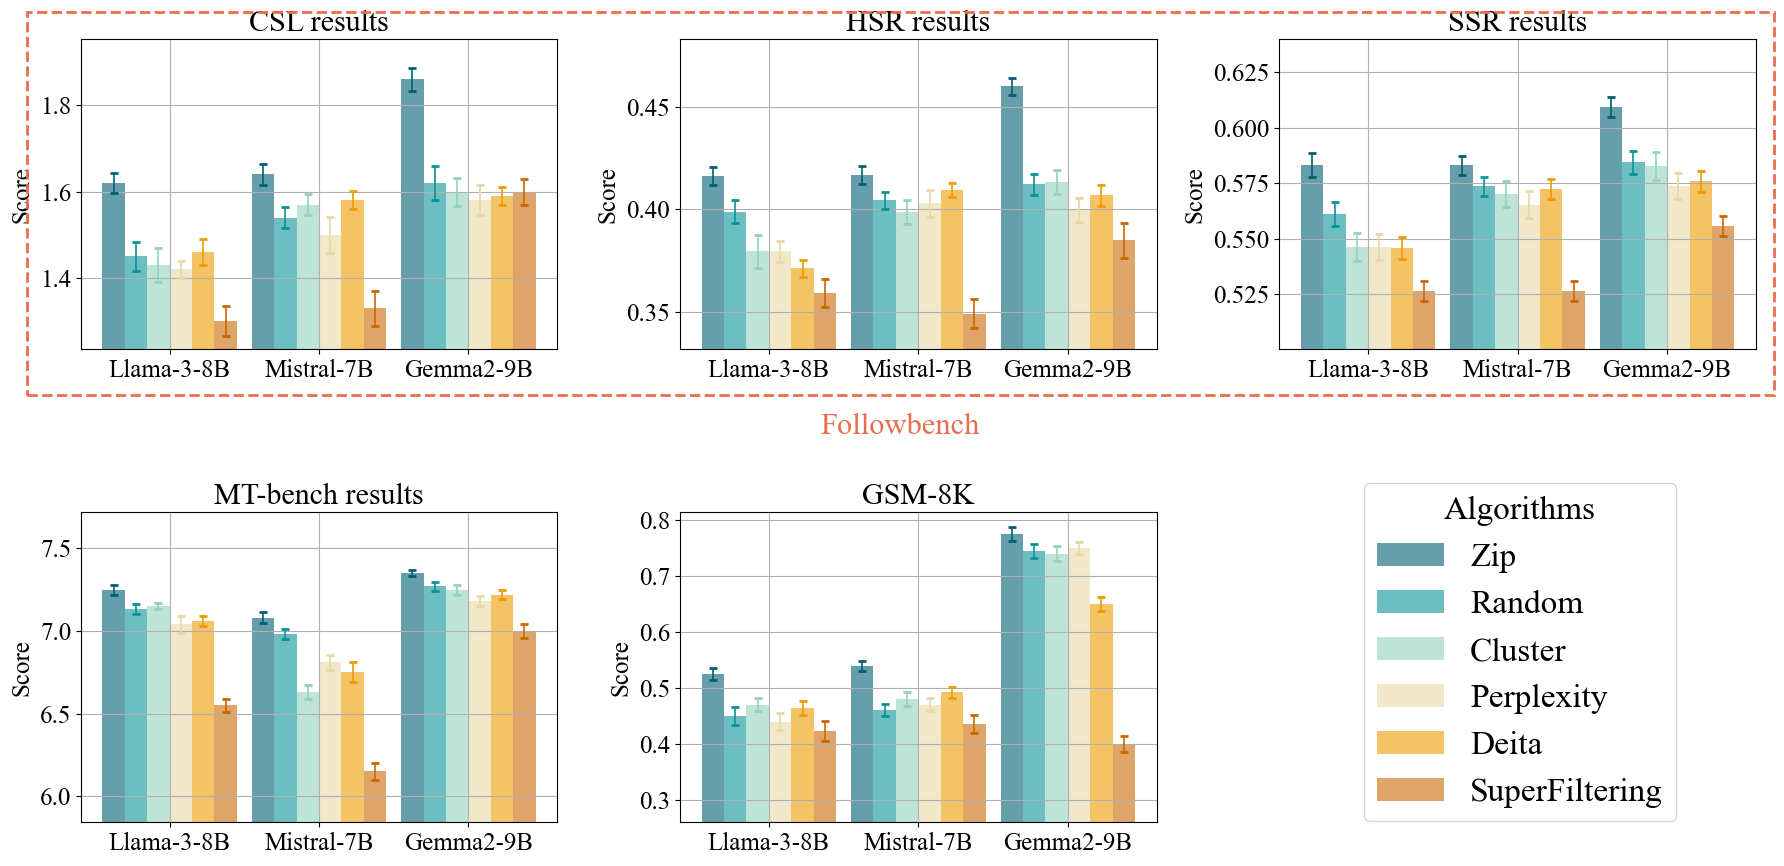

In [17]:
fig, axs = plt.subplots(2, 3, figsize=(18, 9))
axs[1, 2].axis('off')
plot_bars(axs[1, 0], rst_dict1, title='MT-bench results', lengend=True)
plot_bars(axs[1, 1], rst_dict2, title='GSM-8K', min_ratio=0.65)
plot_bars(axs[0, 0], rst_dict3, title='CSL results')
plot_bars(axs[0, 1], rst_dict4, title='HSR results')
plot_bars(axs[0, 2], rst_dict5, title='SSR results')
circle_follow_bench(fig, axs, c='#e76f51')
fig.tight_layout(h_pad=4)
fig.legend(title='Algorithms', loc='lower right', bbox_to_anchor=(0.95, 0.05), ncol=1, title_fontsize=24, prop={'size': 24})
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_rst.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)
plt.show()

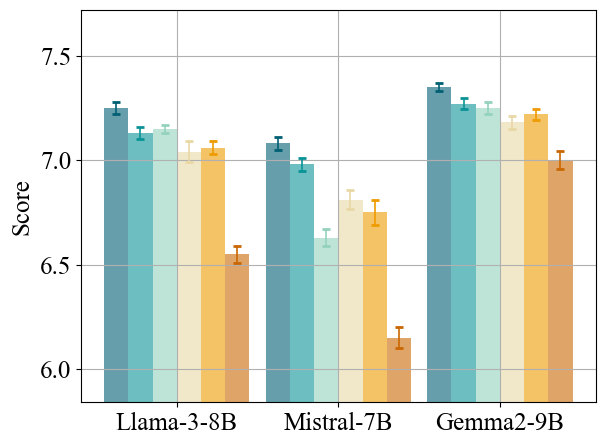

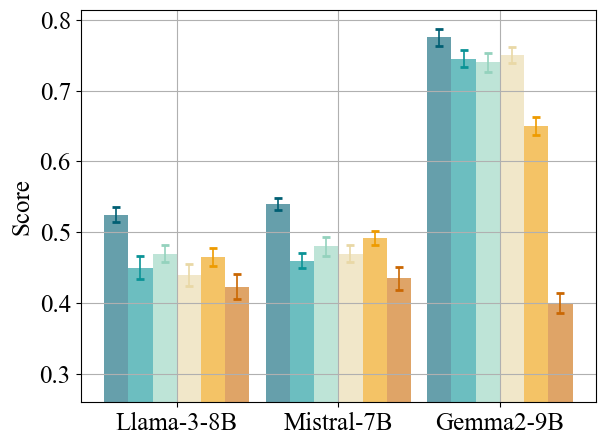

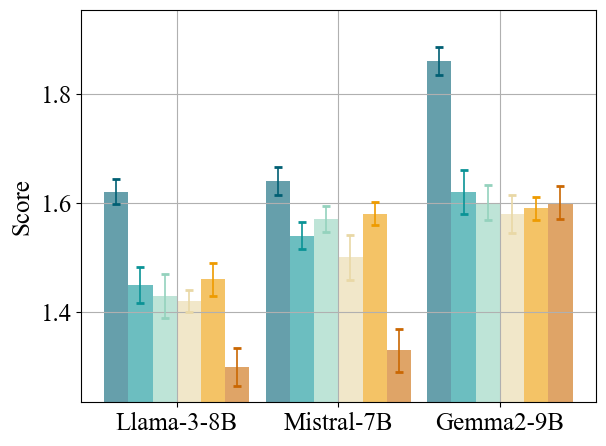

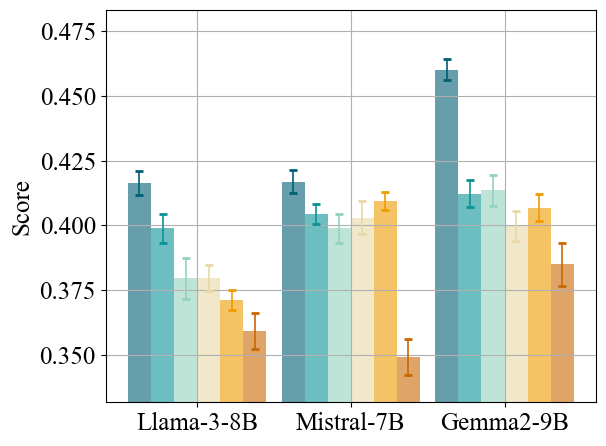

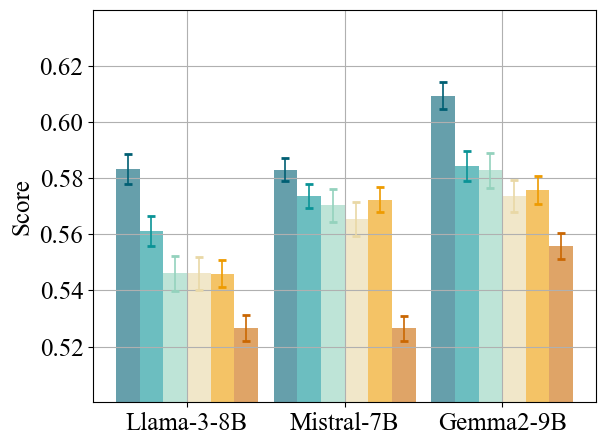

In [18]:
fig, ax = plt.subplots()
plot_bars(ax, rst_dict1)
plt.tight_layout()
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_rst/mt-bench.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)

fig, ax = plt.subplots()
plot_bars(ax, rst_dict2, min_ratio=0.65)
plt.tight_layout()
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_rst/gsm-8k.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)

fig, ax = plt.subplots()
plot_bars(ax, rst_dict3)
plt.tight_layout()
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_rst/csl.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)

fig, ax = plt.subplots()
plot_bars(ax, rst_dict4)
plt.tight_layout()
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_rst/hsr.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)

fig, ax = plt.subplots()
plot_bars(ax, rst_dict5)
plt.tight_layout()
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_rst/ssr.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)



# Plot distribution

# Plot cost

In [19]:
tags

['Zip', 'Random', 'Cluster', 'Perplexity', 'Deita', 'SuperFiltering']

In [20]:
data_length_dict = {
    'Llama-3-8B': [543, 976, 970, 981, 2048, 1579],
    'Mistral-7B': [470, 892, 886, 895, 2048, 1481],
    'Gemma2-9B': [521, 942, 951, 947, 2048, 1521],
}

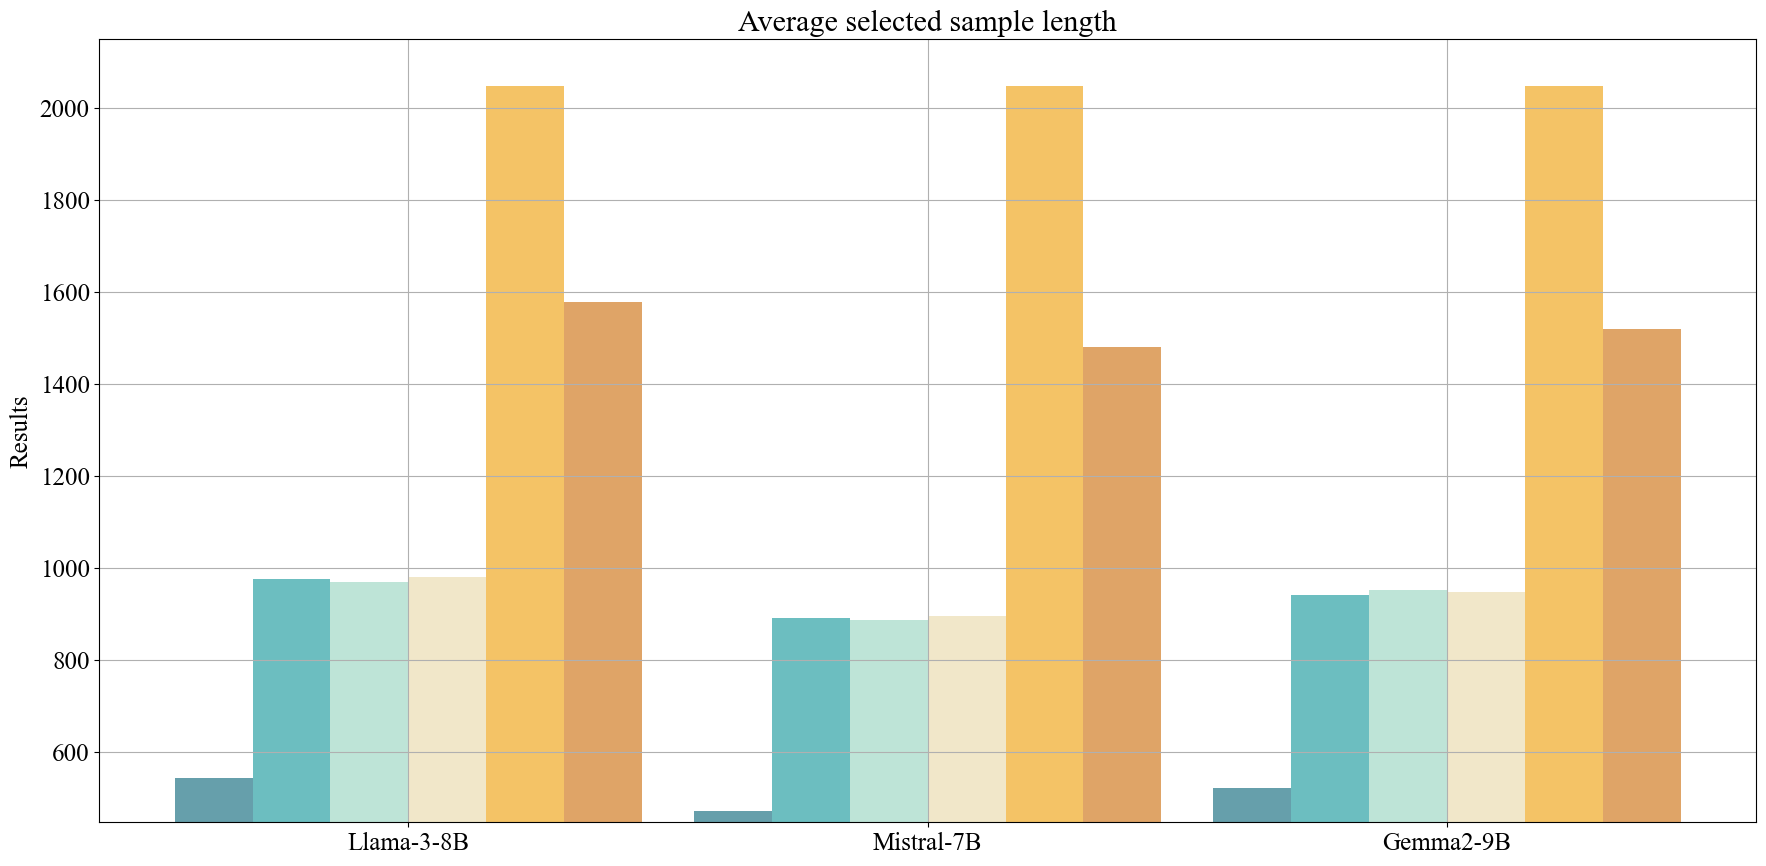

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(18, 9))
plot_bars_wo_var(axs, data_length_dict, title='Average selected sample length', lengend=True)
plt.show()